# Predicting Asteriod Diameter

In [1]:
pip install scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Data Cleaning ( Loading dataset, dropping duplicates and missing values)

In [7]:
df = pd.read_csv("asteroid.csv",low_memory=False)
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

df.drop_duplicates(inplace=True)
print(f"\nRows after duplicate removal: {len(df)}")
df.dropna(subset=["diameter"], inplace=True)
print(f"Rows after dropping missing target: {len(df)}")

threshold = 0.50
df = df[df.columns[df.isnull().mean() < threshold]]
print(f"Columns after dropping high-NA columns: {df.shape[1]}")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

Shape: (958524, 45)
         id    spkid       full_name pdes     name prefix neo pha     H  \
0  a0000001  2000001         1 Ceres    1    Ceres    NaN   N   N  3.40   
1  a0000002  2000002        2 Pallas    2   Pallas    NaN   N   N  4.20   
2  a0000003  2000003          3 Juno    3     Juno    NaN   N   N  5.33   
3  a0000004  2000004         4 Vesta    4    Vesta    NaN   N   N  3.00   
4  a0000005  2000005       5 Astraea    5  Astraea    NaN   N   N  6.90   

   diameter  ...       sigma_i      sigma_om       sigma_w      sigma_ma  \
0   939.400  ...  4.608900e-09  6.168800e-08  6.624800e-08  7.820700e-09   
1   545.000  ...  3.469400e-06  6.272400e-06  9.128200e-06  8.859100e-06   
2   246.596  ...  3.223100e-06  1.664600e-05  1.772100e-05  8.110400e-06   
3   525.400  ...  2.170600e-07  3.880800e-07  1.789300e-07  1.206800e-06   
4   106.699  ...  2.740800e-06  2.894900e-05  2.984200e-05  8.303800e-06   

       sigma_ad       sigma_n      sigma_tp     sigma_per  class      rm

## Categorical Encoding

In [8]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  Encoded: {col}")
 
print("\nData types after encoding:")
print(df.dtypes)

  Encoded: id
  Encoded: full_name
  Encoded: pdes
  Encoded: neo
  Encoded: pha
  Encoded: orbit_id
  Encoded: equinox
  Encoded: class

Data types after encoding:
id                  int64
spkid               int64
full_name           int64
pdes                int64
neo                 int64
pha                 int64
H                 float64
diameter          float64
albedo            float64
diameter_sigma    float64
orbit_id            int64
epoch             float64
epoch_mjd           int64
epoch_cal         float64
equinox             int64
e                 float64
a                 float64
q                 float64
i                 float64
om                float64
w                 float64
ma                float64
ad                float64
n                 float64
tp                float64
tp_cal            float64
per               float64
per_y             float64
moid              float64
moid_ld           float64
sigma_e           float64
sigma_a           float64
sig

## Feature Selection 

In [9]:
# Drop columns that are directly come from target(diameter).
drop_cols = ["diameter", "full_name", "name", "pdes", "id",
             "spkid", "prefix"]          # drop if they exist
drop_cols = [c for c in drop_cols if c in df.columns]
X = df.drop(columns=drop_cols)
y = df["diameter"]
# Picking top 10 features using F-regression 
selector = SelectKBest(score_func=f_regression, k=min(10, X.shape[1]))
selector.fit(X, y)
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()
print("\nSelected features:", selected_features)
X_selected = X[selected_features]


Selected features: ['H', 'diameter_sigma', 'orbit_id', 'a', 'q', 'n', 'moid', 'moid_ld', 'class', 'rms']


## Plotting Selected Features

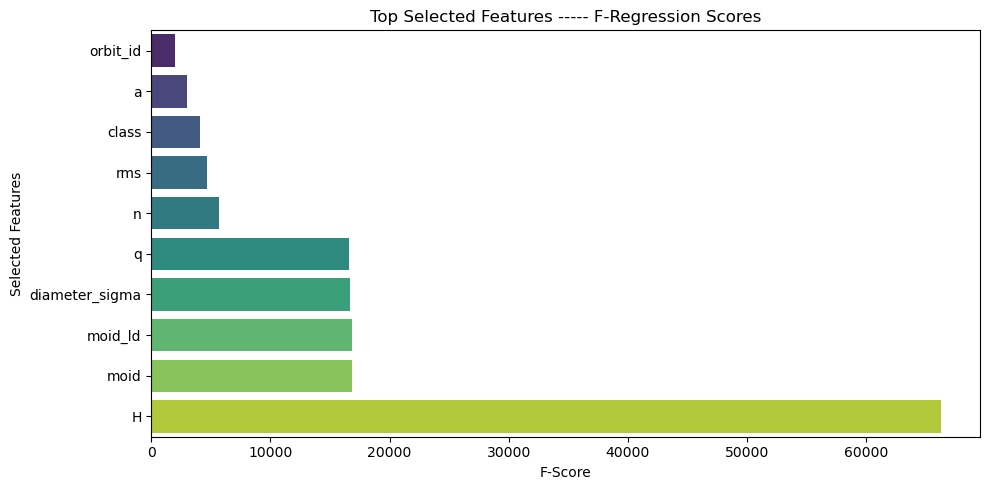

In [10]:
scores = pd.Series(selector.scores_[selected_mask],
                   index= selected_features).sort_values(ascending=True)
plt.figure(figsize = (10,5))
sns.barplot(x=scores.values, y= scores.index,palette="viridis")
plt.title("Top Selected Features ----- F-Regression Scores")
plt.xlabel("F-Score")
plt.ylabel("Selected Features")
plt.tight_layout()
plt.show()

 ## Feature Scaling 

In [11]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_selected),
    columns=selected_features
)
 
print("\nFeature scaling applied: StandardScaler (mean=0, std=1)")
print("\nScaled feature statistics:")
print(X_scaled.describe().round(3))


Feature scaling applied: StandardScaler (mean=0, std=1)

Scaled feature statistics:
                H  diameter_sigma    orbit_id           a           q  \
count  136209.000      136209.000  136209.000  136209.000  136209.000   
mean        0.000          -0.000      -0.000       0.000       0.000   
std         1.000           1.000       1.000       1.000       1.000   
min        -8.879          -0.612      -1.894      -1.466      -4.496   
25%        -0.537          -0.382      -1.172      -0.185      -0.645   
50%         0.048          -0.188       0.354      -0.043      -0.073   
75%         0.633           0.180       0.733       0.184       0.546   
max        10.805         178.293       1.852     249.546      73.341   

                n        moid     moid_ld       class         rms  
count  136209.000  136209.000  136209.000  136209.000  136209.000  
mean        0.000       0.000      -0.000      -0.000       0.000  
std         1.000       1.000       1.000       1.000

## Test and Train Datasets

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Split ratio  : 80% train / 20% test")


Training samples : 108967
Testing  samples : 27242
Split ratio  : 80% train / 20% test


## Fitting decision Tree Model

In [13]:
dt_model = DecisionTreeRegressor(
    max_depth=5,          
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train, y_train)
print("\nDecision Tree trained successfully.")

importances = pd.Series(
    dt_model.feature_importances_,
    index=selected_features
).sort_values(ascending=False)
 
print("\nFeature importances (from Decision Tree):")
print(importances)
 


Decision Tree trained successfully.

Feature importances (from Decision Tree):
H                 0.966997
n                 0.032223
a                 0.000780
diameter_sigma    0.000000
orbit_id          0.000000
q                 0.000000
moid              0.000000
moid_ld           0.000000
class             0.000000
rms               0.000000
dtype: float64


## Model Evaluation


── Model Performance ──
Mean Absolute Error  : 1.4192 km
Mean Squared Error  : 17.7714
Root MSE : 4.2156 km
R**2 Score   : 0.8238


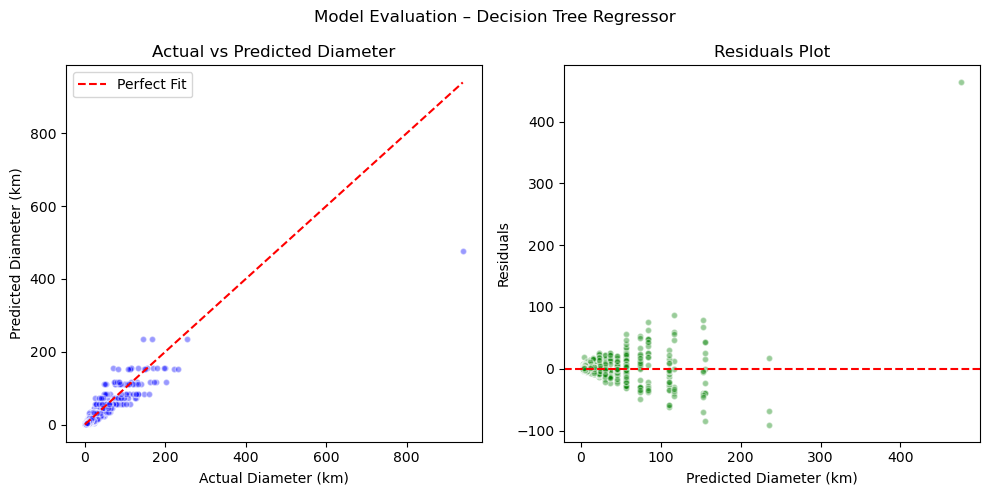

In [14]:
y_pred = dt_model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("\n── Model Performance ──")
print(f"Mean Absolute Error  : {mae:.4f} km")
print(f"Mean Squared Error  : {mse:.4f}")
print(f"Root MSE : {rmse:.4f} km")
print(f"R**2 Score   : {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Model Evaluation – Decision Tree Regressor")
 
axes[0].scatter(y_test, y_pred, alpha=0.4, color="blue", edgecolors="white", s=20)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect Fit")
axes[0].set_title("Actual vs Predicted Diameter")
axes[0].set_xlabel("Actual Diameter (km)")
axes[0].set_ylabel("Predicted Diameter (km)")
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color="green", edgecolors="white", s=20)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Residuals Plot")
axes[1].set_xlabel("Predicted Diameter (km)")
axes[1].set_ylabel("Residuals")
 
plt.tight_layout()
plt.show()

## Plotting Decision Tree

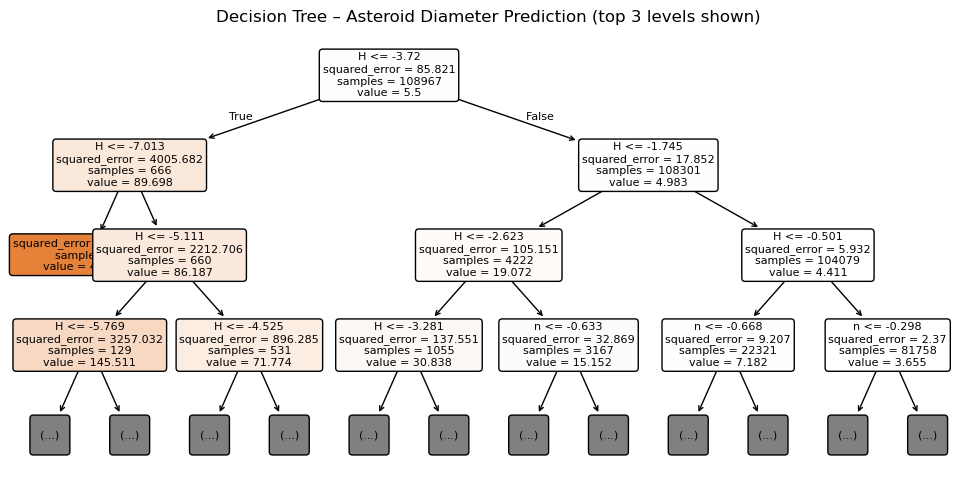

In [16]:
plt.figure(figsize=(10, 5))
plot_tree(
    dt_model,
    feature_names=selected_features,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3         
)
plt.title("Decision Tree – Asteroid Diameter Prediction (top 3 levels shown)")
plt.tight_layout()
plt.show()